In [4]:
import pandas as pd
import numpy as np

print(" Veriler Hugging Face üzerinden orijinal bölümleriyle yükleniyor...")

splits = {
    'train': 'plain_text/train-00000-of-00001.parquet', 
    'test': 'plain_text/test-00000-of-00001.parquet'
}


df_orig_train = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])
df_orig_test = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"])


df_synth = pd.read_csv("/kaggle/input/datasets/batndikilita/datasety/groq_sentetik_10000_ETIKETLI.csv")

print(f" Orijinal Eğitim Seti: {len(df_orig_train)} satır.")
print(f" Orijinal Test Seti: {len(df_orig_test)} satır.")
print(f" Sentetik Veri Havuzu: {len(df_synth)} satır.")

🚀 Veriler Hugging Face üzerinden orijinal bölümleriyle yükleniyor...
✅ Orijinal Eğitim Seti: 25000 satır.
✅ Orijinal Test Seti: 25000 satır.
✅ Sentetik Veri Havuzu: 10000 satır.



🔥 Orijinal Model Eğitiliyor...
Eğitim Veri Sayısı: 25000
Test Veri Sayısı (Gerçek IMDB): 25000
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5231 - loss: 0.6921
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5655 - loss: 0.6706
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5547 - loss: 0.6735
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6172 - loss: 0.6490
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7853 - loss: 0.4900

📊 Orijinal Model -> GERÇEK TEST SETİ SONUÇLARI:
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
              precision    recall  f1-score   support

 Olumsuz (0)       0.88      0.72      0.79     12500
  Olumlu (1)       0.76      0.90      0.83     12500

    accuracy                           0.81     25000
   macro avg       0.82      0.81      0.81     25000
weighted avg       0.82      0.81      0.81     25000



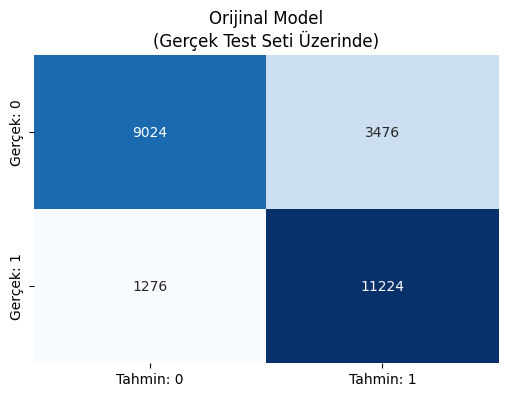


🔥 Sentetik Model Eğitiliyor...
Eğitim Veri Sayısı: 10000
Test Veri Sayısı (Gerçek IMDB): 25000
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5160 - loss: 0.6900
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6300 - loss: 0.6363
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6355 - loss: 0.6652
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7435 - loss: 0.5366
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7201 - loss: 0.5495

📊 Sentetik Model -> GERÇEK TEST SETİ SONUÇLARI:
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
              precision    recall  f1-score   support

 Olumsuz (0)       0.63      0.76      0.69     12500
  Olumlu (1)       0.70      0.55      0.62     12500

    accuracy                           0.66     25000
   macro avg       0.66      0.66      0.65     25000
weighted avg       0.66      0.66      0.65     25000



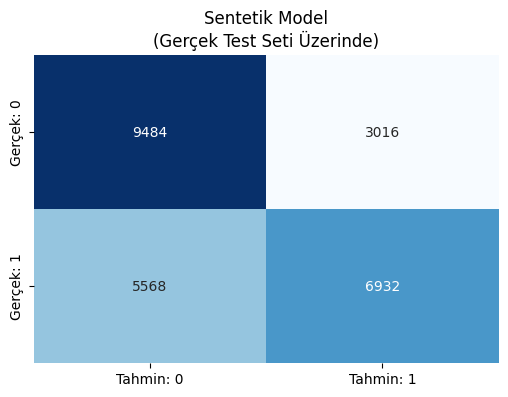

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, TextVectorization
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


VOCAB_SIZE = 10000
MAX_LENGTH = 200
EMBEDDING_DIM = 128
EPOCHS = 5
BATCH_SIZE = 32

X_REAL_TEST = df_orig_test['text'].values
y_REAL_TEST = df_orig_test['label'].values

def train_and_evaluate_on_real(X_train, y_train, model_name):
    print(f"\n{'='*50}")
    print(f" {model_name} Eğitiliyor...")
    print(f"Eğitim Veri Sayısı: {len(X_train)}")
    print(f"Test Veri Sayısı (Gerçek IMDB): {len(X_REAL_TEST)}")
    print(f"{'='*50}")
    
    vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LENGTH)
    vectorizer.adapt(X_train)
    
    model = Sequential([
        vectorizer,
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
        LSTM(64),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)
    
    print(f"\n {model_name} -> GERÇEK TEST SETİ SONUÇLARI:")
    y_pred = (model.predict(X_REAL_TEST) > 0.5).astype(int)
    
    print(classification_report(y_REAL_TEST, y_pred, labels=[0, 1], 
                                target_names=['Olumsuz (0)', 'Olumlu (1)'], zero_division=0))
    
    cm = confusion_matrix(y_REAL_TEST, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Tahmin: 0', 'Tahmin: 1'], 
                yticklabels=['Gerçek: 0', 'Gerçek: 1'])
    plt.title(f'{model_name}\n(Gerçek Test Seti Üzerinde)', fontsize=12)
    plt.show()


train_and_evaluate_on_real(df_orig_train['text'].values, df_orig_train['label'].values, "Orijinal Model")

train_and_evaluate_on_real(df_synth['sentetik'].values, df_synth['label'].values, "Sentetik Model")